In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("RareTechSEA1-60.csv")

In [18]:
pd.set_option('display.max_columns', None)

In [3]:
df.drop(columns=['M', 'Ae', 'Me'], inplace=True)

# Create new columns for calculations
df['delta_T1'] = df['Temp1In'] - df['Temp1Out']
df['efficiency'] = df['Qr'] / df['Q']

In [4]:
df['maintenance_required'] = (
    (df['dP1'] > 100) |
    (df['dP2'] > 100) |
    (df['efficiency'] < 0.7) |
    (df['delta_T1'] < 10)
).astype(int)

# Check label distribution
print(df['maintenance_required'].value_counts())


maintenance_required
1    42316
0    16949
Name: count, dtype: int64


In [8]:
df.drop(columns=['M', 'Ae', 'Me'], errors='ignore', inplace=True)

# Encode categorical fluid IDs if needed
df['Fluid1'] = df['Fluid1'].astype('category').cat.codes
df['Fluid2'] = df['Fluid2'].astype('category').cat.codes

# Define X (features) and y (target)
X = df.drop('maintenance_required', axis=1)
y = df['maintenance_required']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [19]:
df[df['maintenance_required']==0]

,Thickness,Temp1In,Temp1Out,Temp2In,Temp2Out,Fluid1,Fluid2,Q,Qr,Lmtd,Theta1,Theta2,m1,m2,dP1,dP2,V1In,V2In,A,NP,delta_T1,efficiency,maintenance_required
72,0.4,34,18,15,33.065739,25,2,1103.168800,1103.168800,1.770717,9.035888,10.202499,16.971001,14.611000,47.954113,36.867359,2.175760,1.875355,133.500000,267,16,1.0,0
84,0.4,37,26,20,36.744156,27,25,740.405580,740.405580,1.820682,6.041690,9.196637,17.538000,10.886000,57.763180,21.196440,2.084001,1.396925,95.500000,191,11,1.0,0
107,0.4,29,18,15,27.845470,0,25,1749.884300,1749.884200,1.932593,5.691835,6.646754,37.986000,33.511002,54.900196,43.344357,4.862242,4.288179,157.500000,315,11,1.0,0
108,0.4,67,51,46,66.514786,21,3,284.105010,284.105010,1.935514,8.266537,10.599140,9.038000,7.080000,31.310749,34.948704,0.212368,0.166316,726.000000,484,16,1.0,0
150,0.4,61,49,46,59.634434,21,15,91.592331,91.592331,2.076676,5.778464,6.565507,3.910000,3.209000,7.966220,17.922377,0.254363,0.201769,271.560000,438,12,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59217,0.4,75,62,15,20.745321,0,2,485.847050,485.847050,50.540588,0.257219,0.113677,8.947000,20.261000,15.131765,65.659081,1.169146,2.591592,5.280000,24,13,1.0,0
59218,0.4,76,62,15,21.575451,17,5,1187.486100,1187.486100,50.621563,0.276562,0.129894,42.493999,44.249001,72.845634,43.386055,6.271431,5.501867,44.160000,184,14,1.0,0
59239,0.4,76,66,18,19.924864,25,1,291.382450,291.382450,51.932976,0.192556,0.037064,7.077000,36.067001,2.121205,48.397770,0.925533,4.613954,12.759999,58,10,1.0,0
59244,0.4,76,61,15,16.493561,26,5,177.079500,177.079500,52.463776,0.285912,0.028468,3.027000,29.079000,0.768113,21.860996,0.350372,3.608740,18.040001,82,15,1.0,0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3390
           1       1.00      1.00      1.00      8463

    accuracy                           1.00     11853
   macro avg       1.00      1.00      1.00     11853
weighted avg       1.00      1.00      1.00     11853



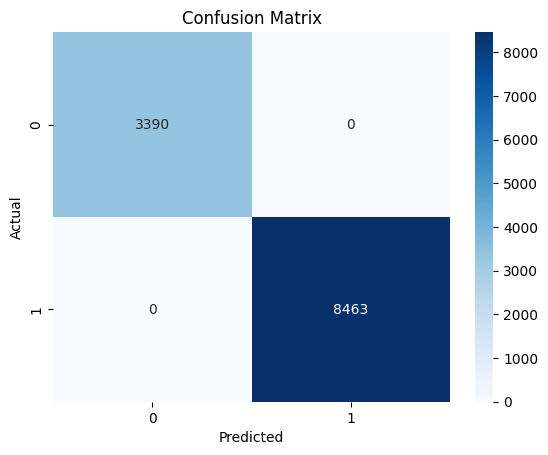

In [11]:
y_pred = model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


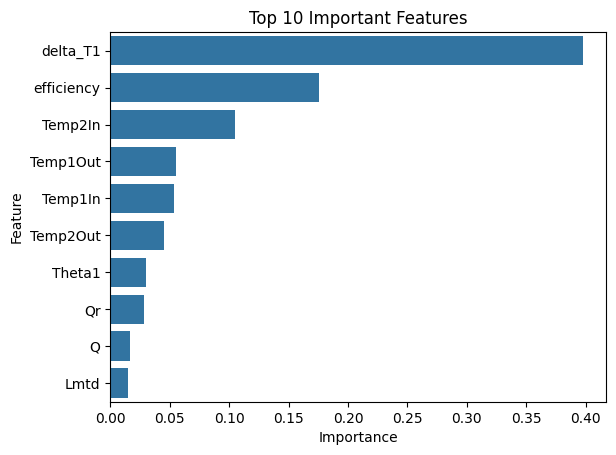

In [12]:
importances = model.feature_importances_
features = X.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot top 10
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()


In [13]:
import pickle
with open('model.pk', 'wb') as file:
    pickle.dump(model, file)